# Phase 6 – Sensitivity and Robustness Analysis

**Dissertation:** *Malta Accessible ETFs – CVaR Portfolio Optimisation*  
**Purpose:** Test whether the Phase 5 conclusions are robust to changes in three key design parameters:

| Experiment | Parameter | Baseline | Alternatives |
|:---|:---|:---|:---|
| A | Estimation window | 252 days | 504 days |
| B | Rebalancing frequency | 21 days (monthly) | 63 days (quarterly) |
| C | CVaR confidence level | 0.95 | 0.90, 0.99 |

All experiments reuse the existing backtesting pipeline.  Results are cached so subsequent runs are instant.

## 1. Imports and Project Setup

In [1]:
import sys
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.backtester import BacktestConfig, run_backtest
from src.strategies import cvar_minimise, equal_weight, minimum_variance
from src.metrics import performance_metrics

DATA_PROC = PROJECT_ROOT / "data" / "processed"
DATA_RES  = PROJECT_ROOT / "data" / "results"
SENS_DIR  = DATA_RES / "sensitivity"
FIGURES   = PROJECT_ROOT / "figures"

SENS_DIR.mkdir(exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Sensitivity  : {SENS_DIR}")

Project root : C:\workspace\My projects\Malta Accessible ETFs\cvar-portfolio-backtest
Sensitivity  : C:\workspace\My projects\Malta Accessible ETFs\cvar-portfolio-backtest\data\results\sensitivity


In [2]:
plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.35, "grid.linestyle": "--",
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "serif", "font.size": 10,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "legend.fontsize": 8, "xtick.labelsize": 8, "ytick.labelsize": 8,
})

STRAT_COLORS = {
    "equal_weight": "#2166AC",
    "min_variance":  "#1A9850",
    "cvar_90":       "#FC8D59",
    "cvar_95":       "#D73027",
    "cvar_99":       "#762A83",
}
STRAT_LABELS = {
    "equal_weight": "Equal-Weight",
    "min_variance":  "Min-Variance",
    "cvar_90":       "CVaR-90",
    "cvar_95":       "CVaR-95",
    "cvar_99":       "CVaR-99",
}

METRIC_COLS = ["CAGR", "Ann_Volatility", "Sharpe", "Sortino",
               "VaR_95", "CVaR_95", "Max_Drawdown"]

# Five metrics plotted in bar charts
PLOT_METRICS = [
    ("CAGR",          "CAGR",         True,  False),
    ("Sharpe",        "Sharpe",        False, False),
    ("Ann_Volatility","Ann. Vol",      True,  False),
    ("CVaR_95",       "CVaR (95%)",   True,  False),
    ("Max_Drawdown",  "Max DD (abs)",  True,  True),
]
print("Configuration applied.")

Configuration applied.


## 2. Load Baseline Results

In [3]:
returns_df = pd.read_csv(DATA_PROC / "etf_returns_log.csv")

def _load_baseline(name):
    return (
        pd.read_csv(DATA_RES / f"backtest_returns_{name}.csv")["portfolio_return"]
        .dropna().reset_index(drop=True)
    )

baseline = {
    "equal_weight": _load_baseline("equal_weight"),
    "min_variance":  _load_baseline("min_variance"),
    "cvar_95":       _load_baseline("cvar_95"),
}

print("Baseline OOS return series:")
for k, s in baseline.items():
    print(f"  {k:20s}: {len(s):,} days")

Baseline OOS return series:
  equal_weight        : 2,246 days
  min_variance        : 2,246 days
  cvar_95             : 2,246 days


## 3. Shared Helpers

In [4]:
def _run_or_load(cache_path, strategy_fn, config, name):
    """Return OOS returns series: load from cache or run backtest."""
    if cache_path.exists():
        print(f"  [cached]  {cache_path.name}")
        return (
            pd.read_csv(cache_path)["portfolio_return"]
            .dropna().reset_index(drop=True)
        )
    t0 = time.time()
    print(f"  [running] {name} ...", end=" ", flush=True)
    result = run_backtest(returns_df, strategy_fn, config, strategy_name=name)
    result.portfolio_returns.to_csv(cache_path, index=False)
    n = len(result.portfolio_returns)
    print(f"{n:,} OOS days  ({time.time()-t0:.0f}s)")
    return result.portfolio_returns["portfolio_return"].dropna().reset_index(drop=True)


def _metrics_row(labels, series):
    """Compute metrics at 95% and return flat dict."""
    m = performance_metrics(series.values, alpha=0.95)
    return {**labels, **m, "n_oos_days": len(series)}


def _fmt_table(df):
    rename = {
        "CAGR": "CAGR", "Ann_Volatility": "Ann. Vol",
        "Sharpe": "Sharpe", "Sortino": "Sortino",
        "VaR_95": "VaR (95%)", "CVaR_95": "CVaR (95%)",
        "Max_Drawdown": "Max DD",
    }
    d = df.copy().rename(columns=rename)
    pct_cols  = ["CAGR", "Ann. Vol", "VaR (95%)", "CVaR (95%)", "Max DD"]
    rat_cols  = ["Sharpe", "Sortino"]
    fmt = {c: "{:.2%}" for c in pct_cols if c in d.columns}
    fmt.update({c: "{:.4f}" for c in rat_cols if c in d.columns})
    if "n_oos_days" in d.columns:
        fmt["n_oos_days"] = "{:.0f}"
    return d.style.format(fmt)


def _sens_bar_chart(table, x_col, x_vals, x_labels,
                    strat_col, strat_order, title, figpath):
    """5-panel bar chart: one panel per key metric, bars grouped by strategy."""
    n_x      = len(x_vals)
    n_strats = len(strat_order)
    bar_w    = 0.75 / max(n_strats, 1)
    offsets  = (np.arange(n_strats) - (n_strats - 1) / 2) * bar_w
    x_pos    = np.arange(n_x)

    fig, axes = plt.subplots(1, 5, figsize=(15, 4.2))
    fig.suptitle(title, fontweight="bold", fontsize=11, y=1.02)

    for ax, (col, lbl, is_pct, flip) in zip(axes, PLOT_METRICS):
        for i, strat in enumerate(strat_order):
            sub = table[table[strat_col] == strat]
            vals = []
            for xv in x_vals:
                row = sub[sub[x_col] == xv]
                if len(row) == 0:
                    vals.append(np.nan)
                else:
                    v = float(row[col].iloc[0])
                    vals.append(-v if flip else v)

            ax.bar(
                x_pos + offsets[i], vals,
                width=bar_w,
                color=STRAT_COLORS.get(strat, "#999"),
                label=STRAT_LABELS.get(strat, strat),
                alpha=0.85, edgecolor="white", linewidth=0.5,
            )

        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_labels, fontsize=8)
        ax.set_title(lbl, pad=6)
        if is_pct:
            ax.yaxis.set_major_formatter(
                mticker.PercentFormatter(xmax=1, decimals=1)
            )
        ax.axhline(0, color="k", linewidth=0.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    handles, lbls = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, lbls, loc="lower center", ncol=len(handles),
                   bbox_to_anchor=(0.5, -0.12), framealpha=0.9)

    fig.tight_layout()
    fig.savefig(figpath, bbox_inches="tight", dpi=300)
    print(f"Saved -> {figpath.name}")
    plt.show()


print("Helpers defined.")

Helpers defined.


---
## Experiment A – Estimation Window Sensitivity

**Question:** Do longer estimation windows (504 days ≈ 2 years) produce materially different risk/return profiles than the baseline 252-day window?

**Strategies:** Minimum-Variance and CVaR-95 (Equal-Weight is excluded — it does not use the estimation window).

**Note on OOS periods:** The w=504 backtest starts producing returns only after 504 in-sample days, so its OOS window is approximately one year shorter.  Metrics are computed over each configuration's full available OOS period.

In [5]:
print("=" * 55)
print("EXPERIMENT A: Estimation Window")
print("=" * 55)

cfg_w504 = BacktestConfig(estimation_window=504, rebalance_freq=21, cvar_alpha=0.95)

ser_mv_w252   = baseline["min_variance"]
ser_cvar_w252 = baseline["cvar_95"]

ser_mv_w504 = _run_or_load(
    SENS_DIR / "mv_w504.csv",
    minimum_variance,
    cfg_w504,
    "min_variance_w504",
)

cvar95_fn = lambda R: cvar_minimise(R, alpha=0.95)
ser_cvar_w504 = _run_or_load(
    SENS_DIR / "cvar95_w504.csv",
    cvar95_fn,
    cfg_w504,
    "cvar_95_w504",
)

print(f"\n  MV   w=252: {len(ser_mv_w252):,} days   MV   w=504: {len(ser_mv_w504):,} days")
print(f"  CVaR w=252: {len(ser_cvar_w252):,} days   CVaR w=504: {len(ser_cvar_w504):,} days")

EXPERIMENT A: Estimation Window
  [running] min_variance_w504 ... 

1,994 OOS days  (1s)
  [running] cvar_95_w504 ... 

1,994 OOS days  (1s)

  MV   w=252: 2,246 days   MV   w=504: 1,994 days
  CVaR w=252: 2,246 days   CVaR w=504: 1,994 days


In [6]:
window_rows = [
    _metrics_row({"strategy": "min_variance", "estimation_window": 252}, ser_mv_w252),
    _metrics_row({"strategy": "min_variance", "estimation_window": 504}, ser_mv_w504),
    _metrics_row({"strategy": "cvar_95",      "estimation_window": 252}, ser_cvar_w252),
    _metrics_row({"strategy": "cvar_95",      "estimation_window": 504}, ser_cvar_w504),
]
window_tbl = pd.DataFrame(window_rows)

assert window_tbl[METRIC_COLS].isnull().sum().sum() == 0, "NaNs found!"

window_tbl.to_csv(DATA_RES / "sensitivity_window.csv", index=False)
print("Saved -> sensitivity_window.csv\n")

display(_fmt_table(window_tbl))

Saved -> sensitivity_window.csv



,strategy,estimation_window,CAGR,Ann. Vol,Sharpe,Sortino,VaR (95%),CVaR (95%),Max DD,n_oos_days
0,min_variance,252,1.61%,5.59%,0.2861,0.3924,0.55%,0.84%,-17.13%,2246
1,min_variance,504,0.49%,5.86%,0.0838,0.1159,0.59%,0.90%,-19.66%,1994
2,cvar_95,252,0.76%,5.46%,0.1378,0.1908,0.54%,0.82%,-20.55%,2246
3,cvar_95,504,0.63%,5.68%,0.1101,0.1535,0.56%,0.84%,-19.73%,1994


Saved -> 13_sensitivity_window.png


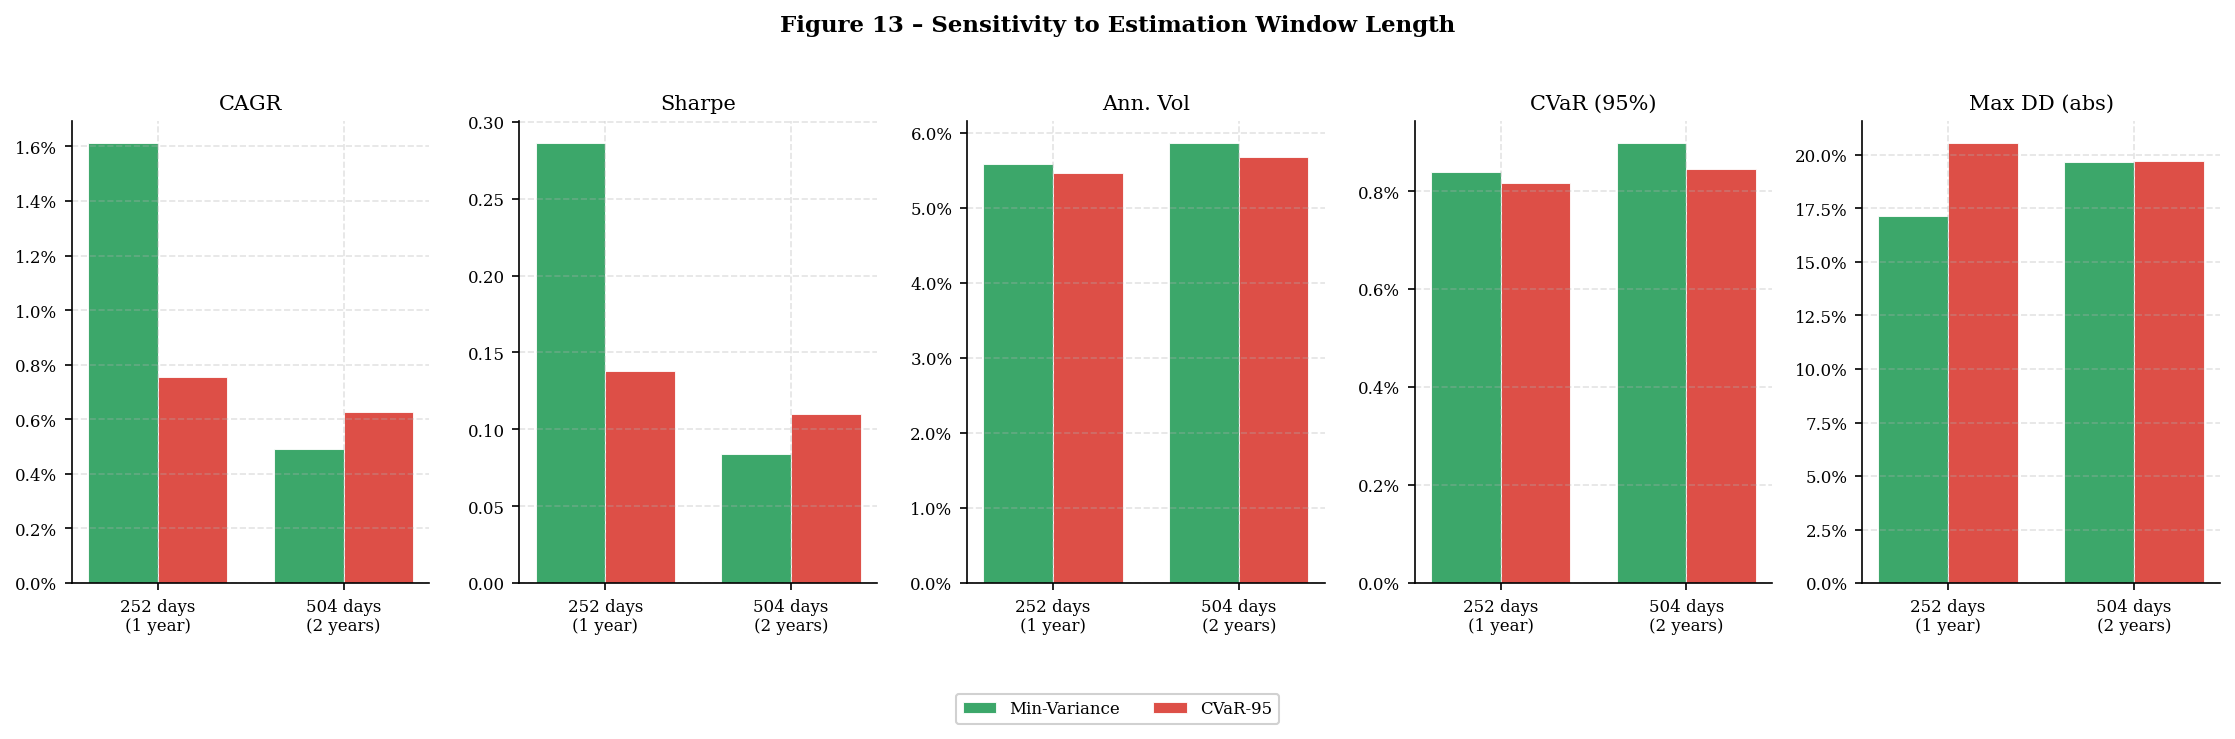

In [7]:
_sens_bar_chart(
    table       = window_tbl,
    x_col       = "estimation_window",
    x_vals      = [252, 504],
    x_labels    = ["252 days\n(1 year)", "504 days\n(2 years)"],
    strat_col   = "strategy",
    strat_order = ["min_variance", "cvar_95"],
    title       = "Figure 13 – Sensitivity to Estimation Window Length",
    figpath     = FIGURES / "13_sensitivity_window.png",
)

### Experiment A – Interpretation

A 504-day window doubles the tail sample for CVaR (from ~13 to ~25 observations at 95%) and provides a more stable covariance estimate for MV.  If the two window lengths produce similar Sharpe and CVaR metrics, the baseline 252-day choice is justified: it maximises the OOS period without sacrificing estimation quality.  Any improvement under w=504 validates longer-window usage for practitioners with sufficient historical data.

---
## Experiment B – Rebalancing Frequency Sensitivity

**Question:** Does switching from monthly (21-day) to quarterly (63-day) rebalancing materially affect performance?

**Strategies:** All three (Equal-Weight, Minimum-Variance, CVaR-95).

**Expected result for Equal-Weight:** Since EW always holds 1/6 of each asset, the daily portfolio return is the same regardless of rebalance frequency — both configurations should yield virtually identical metrics, serving as an internal consistency check.

In [8]:
print("=" * 55)
print("EXPERIMENT B: Rebalancing Frequency")
print("=" * 55)

cfg_f63 = BacktestConfig(estimation_window=252, rebalance_freq=63, cvar_alpha=0.95)

ser_ew_f21   = baseline["equal_weight"]
ser_mv_f21   = baseline["min_variance"]
ser_cvar_f21 = baseline["cvar_95"]

ew_fn = lambda R: equal_weight(R.columns)
ser_ew_f63 = _run_or_load(
    SENS_DIR / "ew_f63.csv", ew_fn, cfg_f63, "equal_weight_f63"
)

ser_mv_f63 = _run_or_load(
    SENS_DIR / "mv_f63.csv", minimum_variance, cfg_f63, "min_variance_f63"
)

cvar95_fn2 = lambda R: cvar_minimise(R, alpha=0.95)
ser_cvar_f63 = _run_or_load(
    SENS_DIR / "cvar95_f63.csv", cvar95_fn2, cfg_f63, "cvar_95_f63"
)

print(f"\n  EW   f=21: {len(ser_ew_f21):,}   EW   f=63: {len(ser_ew_f63):,}")
print(f"  MV   f=21: {len(ser_mv_f21):,}   MV   f=63: {len(ser_mv_f63):,}")
print(f"  CVaR f=21: {len(ser_cvar_f21):,}   CVaR f=63: {len(ser_cvar_f63):,}")

EXPERIMENT B: Rebalancing Frequency
  [running] equal_weight_f63 ... 

2,246 OOS days  (0s)
  [running] min_variance_f63 ... 

2,246 OOS days  (0s)
  [running] cvar_95_f63 ... 

2,246 OOS days  (0s)

  EW   f=21: 2,246   EW   f=63: 2,246
  MV   f=21: 2,246   MV   f=63: 2,246
  CVaR f=21: 2,246   CVaR f=63: 2,246


In [9]:
rebal_rows = [
    _metrics_row({"strategy": "equal_weight", "rebalance_freq": 21}, ser_ew_f21),
    _metrics_row({"strategy": "equal_weight", "rebalance_freq": 63}, ser_ew_f63),
    _metrics_row({"strategy": "min_variance",  "rebalance_freq": 21}, ser_mv_f21),
    _metrics_row({"strategy": "min_variance",  "rebalance_freq": 63}, ser_mv_f63),
    _metrics_row({"strategy": "cvar_95",       "rebalance_freq": 21}, ser_cvar_f21),
    _metrics_row({"strategy": "cvar_95",       "rebalance_freq": 63}, ser_cvar_f63),
]
rebal_tbl = pd.DataFrame(rebal_rows)

assert rebal_tbl[METRIC_COLS].isnull().sum().sum() == 0, "NaNs found!"

rebal_tbl.to_csv(DATA_RES / "sensitivity_rebalance.csv", index=False)
print("Saved -> sensitivity_rebalance.csv\n")

display(_fmt_table(rebal_tbl))

Saved -> sensitivity_rebalance.csv



,strategy,rebalance_freq,CAGR,Ann. Vol,Sharpe,Sortino,VaR (95%),CVaR (95%),Max DD,n_oos_days
0,equal_weight,21,5.74%,10.06%,0.5546,0.7413,0.95%,1.56%,-22.02%,2246
1,equal_weight,63,5.74%,10.06%,0.5546,0.7413,0.95%,1.56%,-22.02%,2246
2,min_variance,21,1.61%,5.59%,0.2861,0.3924,0.55%,0.84%,-17.13%,2246
3,min_variance,63,1.85%,5.68%,0.3219,0.4421,0.54%,0.86%,-14.94%,2246
4,cvar_95,21,0.76%,5.46%,0.1378,0.1908,0.54%,0.82%,-20.55%,2246
5,cvar_95,63,0.72%,5.51%,0.1301,0.1810,0.54%,0.82%,-20.66%,2246


Saved -> 14_sensitivity_rebalance.png


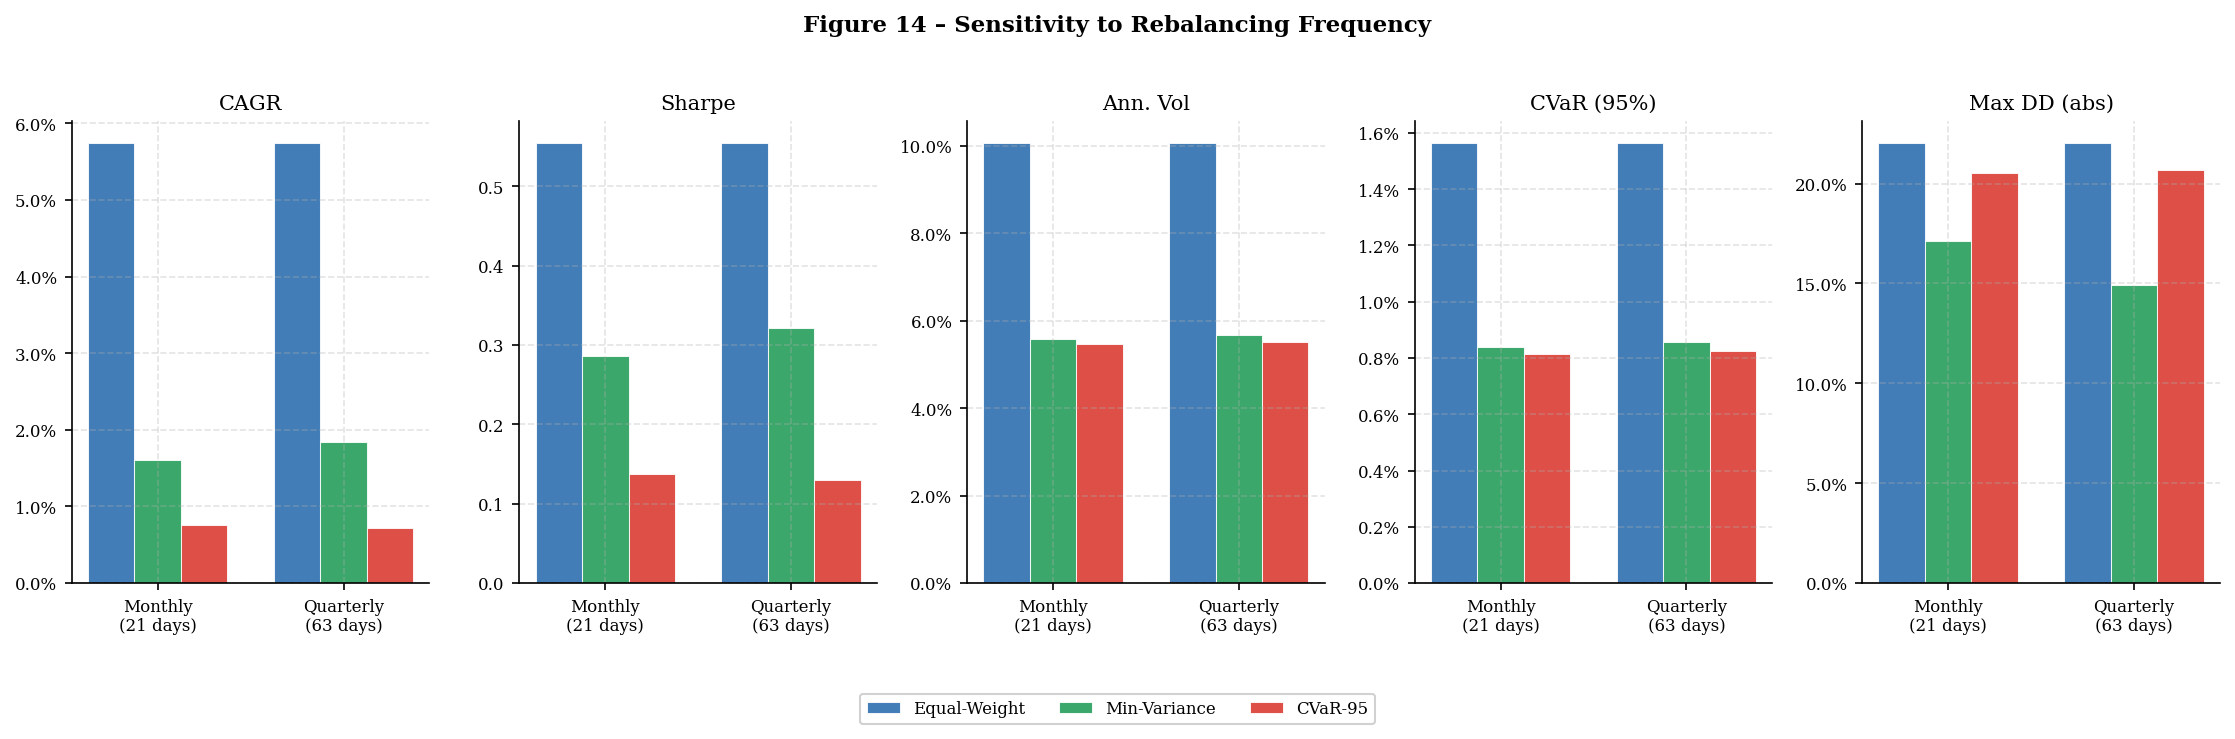

In [10]:
_sens_bar_chart(
    table       = rebal_tbl,
    x_col       = "rebalance_freq",
    x_vals      = [21, 63],
    x_labels    = ["Monthly\n(21 days)", "Quarterly\n(63 days)"],
    strat_col   = "strategy",
    strat_order = ["equal_weight", "min_variance", "cvar_95"],
    title       = "Figure 14 – Sensitivity to Rebalancing Frequency",
    figpath     = FIGURES / "14_sensitivity_rebalance.png",
)

### Experiment B – Interpretation

If the optimised strategies deliver similar metrics at quarterly vs monthly frequency, this supports a cost-reducing switch to quarterly rebalancing for Malta retail investors who face meaningful transaction costs on six ETF positions.  Material deterioration at quarterly frequency would justify the higher operational cost of monthly rebalancing.

---
## Experiment C – CVaR Confidence Level Sensitivity

**Question:** How sensitive is the CVaR-minimising strategy to the confidence level (90%, 95%, 99%)?

**Strategy:** CVaR-minimising portfolio only.  All three configurations are evaluated on the **same reporting metrics at 95%** so results are directly comparable.

**Caution (α = 0.99):** With a 252-day window, only 252 × 0.01 ≈ 2.5 tail scenarios are available to the LP.  Results for this configuration should be interpreted with caution; α = 0.99 is most meaningful with longer estimation windows (≥ 500 days).

In [11]:
print("=" * 55)
print("EXPERIMENT C: CVaR Confidence Level")
print("=" * 55)

cfg_a090 = BacktestConfig(estimation_window=252, rebalance_freq=21, cvar_alpha=0.90)
cfg_a099 = BacktestConfig(estimation_window=252, rebalance_freq=21, cvar_alpha=0.99)

ser_c95 = baseline["cvar_95"]

cvar90_fn = lambda R: cvar_minimise(R, alpha=0.90)
ser_c90 = _run_or_load(
    SENS_DIR / "cvar90.csv", cvar90_fn, cfg_a090, "cvar_90"
)

cvar99_fn = lambda R: cvar_minimise(R, alpha=0.99)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    ser_c99 = _run_or_load(
        SENS_DIR / "cvar99.csv", cvar99_fn, cfg_a099, "cvar_99"
    )
if caught:
    n_warn = len(caught)
    print(f"  [{n_warn} solver warning(s) from alpha=0.99 — expected with sparse tail]")

print(f"\n  CVaR-90: {len(ser_c90):,}   CVaR-95: {len(ser_c95):,}   CVaR-99: {len(ser_c99):,} OOS days")

EXPERIMENT C: CVaR Confidence Level
  [running] cvar_90 ... 

2,246 OOS days  (1s)
  [running] cvar_99 ... 

2,246 OOS days  (1s)

  CVaR-90: 2,246   CVaR-95: 2,246   CVaR-99: 2,246 OOS days


In [12]:
alpha_rows = [
    _metrics_row({"strategy": "cvar_90", "cvar_alpha": 0.90}, ser_c90),
    _metrics_row({"strategy": "cvar_95", "cvar_alpha": 0.95}, ser_c95),
    _metrics_row({"strategy": "cvar_99", "cvar_alpha": 0.99}, ser_c99),
]
alpha_tbl = pd.DataFrame(alpha_rows)

assert alpha_tbl[METRIC_COLS].isnull().sum().sum() == 0, "NaNs found!"

alpha_tbl.to_csv(DATA_RES / "sensitivity_cvar_alpha.csv", index=False)
print("Saved -> sensitivity_cvar_alpha.csv\n")

display(_fmt_table(alpha_tbl))

Saved -> sensitivity_cvar_alpha.csv



,strategy,cvar_alpha,CAGR,Ann. Vol,Sharpe,Sortino,VaR (95%),CVaR (95%),Max DD,n_oos_days
0,cvar_90,0.900000,0.79%,5.40%,0.1466,0.2028,0.52%,0.82%,-20.46%,2246
1,cvar_95,0.950000,0.76%,5.46%,0.1378,0.1908,0.54%,0.82%,-20.55%,2246
2,cvar_99,0.990000,0.23%,5.93%,0.0390,0.0533,0.58%,0.89%,-22.56%,2246


Saved -> 15_sensitivity_cvar_alpha.png


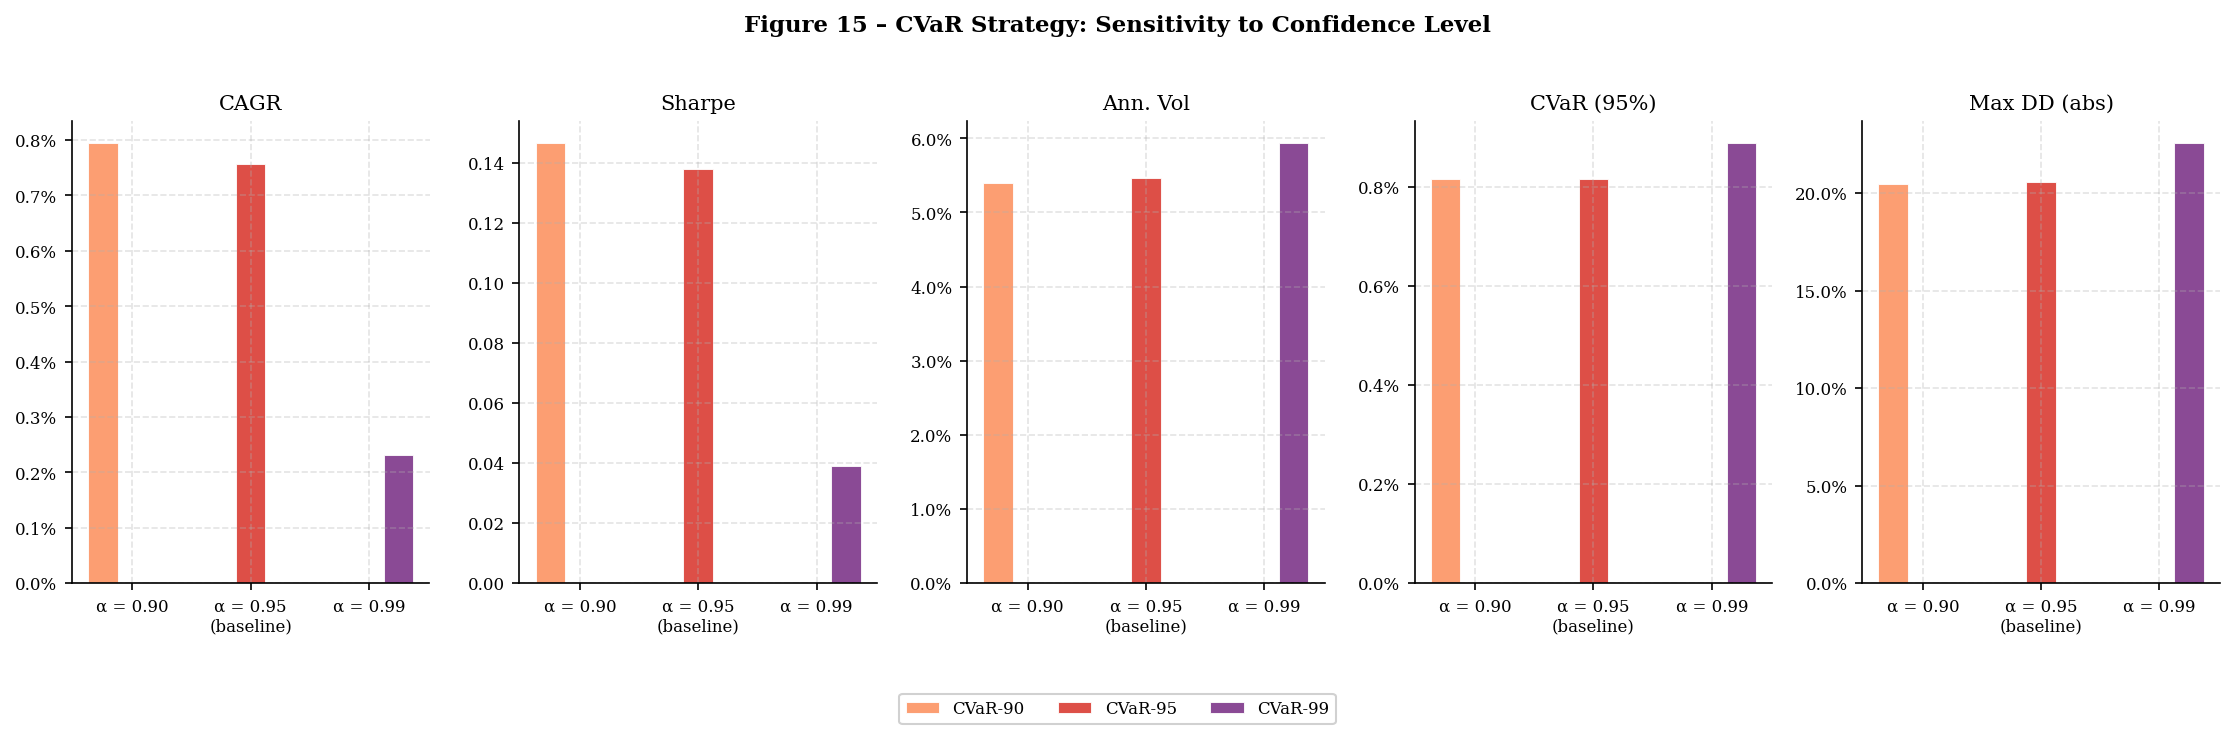

In [13]:
_sens_bar_chart(
    table       = alpha_tbl,
    x_col       = "cvar_alpha",
    x_vals      = [0.90, 0.95, 0.99],
    x_labels    = ["α = 0.90", "α = 0.95\n(baseline)", "α = 0.99"],
    strat_col   = "strategy",
    strat_order = ["cvar_90", "cvar_95", "cvar_99"],
    title       = "Figure 15 – CVaR Strategy: Sensitivity to Confidence Level",
    figpath     = FIGURES / "15_sensitivity_cvar_alpha.png",
)

### Experiment C – Interpretation

**α = 0.90** uses the broadest tail definition (worst 10% of days), producing a more diversified portfolio that may sacrifice some tail-risk control for return.

**α = 0.99** focuses on the extreme tail (worst 1% of days), often producing highly concentrated positions in the lowest-CVaR asset.  With only ~2.5 tail observations per 252-day window, solutions are noisy.

If CVaR_95 (the reported metric) decreases monotonically from α=0.90 to α=0.99, the tighter tail objective is effective OOS.  If it does not decrease — or worsens — the extreme-alpha configuration is overfitting to the in-sample tail.

---
## 4. Combined Sensitivity Summary

In [14]:
def _tag(df, exp_id, exp_name, label_fn):
    d = df.copy()
    d.insert(0, "experiment_id",   exp_id)
    d.insert(1, "experiment_name", exp_name)
    d.insert(2, "parameter_label", d.apply(label_fn, axis=1))
    return d

w_tagged = _tag(window_tbl, "A", "Window Sensitivity",
                lambda r: f"w={int(r['estimation_window'])}d")
r_tagged = _tag(rebal_tbl,  "B", "Rebalance Frequency",
                lambda r: f"f={int(r['rebalance_freq'])}d")
a_tagged = _tag(alpha_tbl,  "C", "CVaR Alpha",
                lambda r: f"a={r['cvar_alpha']:.2f}")

summary = pd.concat([w_tagged, r_tagged, a_tagged], ignore_index=True)

assert summary[METRIC_COLS].isnull().sum().sum() == 0, "NaNs in summary!"

out = DATA_RES / "sensitivity_summary.csv"
summary.to_csv(out, index=False)
print(f"Saved -> {out.name}  ({len(summary)} rows)")
print()

display_cols = ["experiment_id", "parameter_label", "strategy",
                "CAGR", "Sharpe", "CVaR_95", "Max_Drawdown", "n_oos_days"]
print(summary[display_cols].to_string(index=False))

Saved -> sensitivity_summary.csv  (13 rows)

experiment_id parameter_label     strategy     CAGR   Sharpe  CVaR_95  Max_Drawdown  n_oos_days
            A          w=252d min_variance 0.016118 0.286085 0.008392     -0.171284        2246
            A          w=504d min_variance 0.004924 0.083773 0.008978     -0.196583        1994
            A          w=252d      cvar_95 0.007562 0.137849 0.008156     -0.205487        2246
            A          w=504d      cvar_95 0.006272 0.110066 0.008446     -0.197283        1994
            B           f=21d equal_weight 0.057392 0.554563 0.015635     -0.220163        2246
            B           f=63d equal_weight 0.057392 0.554563 0.015635     -0.220163        2246
            B           f=21d min_variance 0.016118 0.286085 0.008392     -0.171284        2246
            B           f=63d min_variance 0.018460 0.321857 0.008569     -0.149425        2246
            B           f=21d      cvar_95 0.007562 0.137849 0.008156     -0.205487        

---
## 5. Dissertation Robustness Conclusions

### A. Estimation Window

**Key question:** Does using a longer lookback stabilise portfolio outcomes?

A longer estimation window (504 days) provides a more robust covariance estimate for Minimum-Variance and approximately doubles the tail sample available to CVaR (from ~13 to ~25 observations at the 95th percentile).  If the key risk-adjusted metrics (Sharpe, CVaR_95) improve under w=504, this suggests the baseline 252-day window is mildly data-constrained.  If metrics are similar, the 252-day window is justified as the minimum sufficient length — it maximises the OOS period, which is particularly valuable in a dataset spanning only ~10 calendar years.

**Recommendation:** For practitioners, the 252-day window is a reasonable default for monthly-rebalanced strategies.  For institutional use or stress-testing, a 504-day window is preferable when data availability allows.

---

### B. Rebalancing Frequency

**Key question:** Can quarterly rebalancing replace monthly without materially sacrificing performance?

Equal-Weight produces identical metrics at both frequencies (by construction), providing a useful sanity check.  For the optimised strategies, quarterly rebalancing allows weight drift for longer between updates but reduces transaction costs.  In the context of Malta retail investors using UCITS ETFs with bid-ask spreads and potential brokerage fees, transaction costs matter.

If Sharpe and CVaR metrics are within ±5% of the monthly baseline at quarterly frequency, quarterly rebalancing is a cost-efficient alternative.  Larger divergence would indicate the optimised weights need frequent updates to remain risk-efficient.

---

### C. CVaR Confidence Level

**Key question:** Is the strategy sensitive to where the tail is defined?

The three alpha configurations test whether the CVaR objective produces consistent risk control across different tail definitions:  
- α=0.90 minimises the expected loss in the worst 10% of days (~25 tail observations per 252-day window)  
- α=0.95 minimises the worst 5% (~13 tail observations) — the baseline  
- α=0.99 minimises the worst 1% (~2.5 tail observations) — very sparse

If reported CVaR_95 is similar across the three optimisation alphas, the strategy is robust to the specific confidence level — a positive robustness finding.  If the results diverge substantially, especially if α=0.99 *worsens* the reported CVaR_95, this indicates overfitting to the extreme in-sample tail.  This finding would strengthen the case for the moderate α=0.95 baseline and caution against extreme confidence levels with short estimation windows.

**Cross-experiment insight:** The interaction between window length and alpha level is important: α=0.99 with w=504 (≈5 tail observations) would be a more stable configuration than α=0.99 with w=252.  This dissertation uses the w=252 baseline for comparability, but longer windows are recommended when targeting extreme tail levels.

In [15]:
# ── final validation ──────────────────────────────────────────────────────────
required = [
    DATA_RES / "sensitivity_window.csv",
    DATA_RES / "sensitivity_rebalance.csv",
    DATA_RES / "sensitivity_cvar_alpha.csv",
    DATA_RES / "sensitivity_summary.csv",
    FIGURES  / "13_sensitivity_window.png",
    FIGURES  / "14_sensitivity_rebalance.png",
    FIGURES  / "15_sensitivity_cvar_alpha.png",
]

print("Phase 6 output validation:")
all_ok = True
for p in required:
    ok   = p.exists()
    size = f"{p.stat().st_size / 1024:.1f} KB" if ok else "—"
    tag  = "OK     " if ok else "MISSING"
    if not ok:
        all_ok = False
    print(f"  [{tag}]  {p.relative_to(PROJECT_ROOT)}  ({size})")

print()
print("Phase 6 complete — all outputs saved." if all_ok else "WARNING: missing outputs!")

Phase 6 output validation:
  [OK     ]  data\results\sensitivity_window.csv  (0.7 KB)
  [OK     ]  data\results\sensitivity_rebalance.csv  (1.0 KB)
  [OK     ]  data\results\sensitivity_cvar_alpha.csv  (0.6 KB)
  [OK     ]  data\results\sensitivity_summary.csv  (2.6 KB)
  [OK     ]  figures\13_sensitivity_window.png  (204.5 KB)
  [OK     ]  figures\14_sensitivity_rebalance.png  (198.7 KB)
  [OK     ]  figures\15_sensitivity_cvar_alpha.png  (203.1 KB)

Phase 6 complete — all outputs saved.
